# GARCH 模型：上证综指波动率建模

本 Notebook 对上证综指日对数收益率拟合 GARCH 模型，
刻画波动率聚集现象并进行样本外波动率预测。

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import src.plot_config

from src.data_loader import load_train, load_test
from src.preprocess import preprocess
from src.eda import check_stationarity
from src.garch_model import (
    prepare_returns, search_garch_order,
    garch_diagnostics, rolling_forecast_garch
)

FIGURES = ROOT / 'outputs' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. 数据准备

加载并预处理训练数据，提取对数收益率序列，
并通过 ADF 检验验证其平稳性。

In [2]:
raw_train = load_train()
df_train = preprocess(raw_train)
print(f'训练集: {df_train.index.min().date()} ~ {df_train.index.max().date()}, {len(df_train)} 条')

returns = df_train['log_return']
print(f'\n收益率序列长度: {len(returns)}')
returns.describe()

训练集: 2016-01-05 ~ 2020-12-31, 1217 条

收益率序列长度: 1217


count    1217.000000
mean        0.000043
std         0.011701
min        -0.080392
25%        -0.004921
50%         0.000579
75%         0.005348
max         0.055542
Name: log_return, dtype: float64

In [3]:
adf_result = check_stationarity(returns)
display(adf_result)
if adf_result['is_stationary'].iloc[0]:
    print('✓ 对数收益率序列平稳，可以直接进行 GARCH 建模')
else:
    print('✗ 序列非平稳，请检查数据')

,adf_statistic,p_value,critical_1%,critical_5%,critical_10%,is_stationary
log_return,-15.992226,6.651586e-29,-3.435761,-2.86393,-2.568042,True


✓ 对数收益率序列平稳，可以直接进行 GARCH 建模


## 2. 波动率聚集观察

绘制收益率和收益率平方（波动率代理指标），
直观观察波动率聚集现象：高波动率时期往往连续出现。

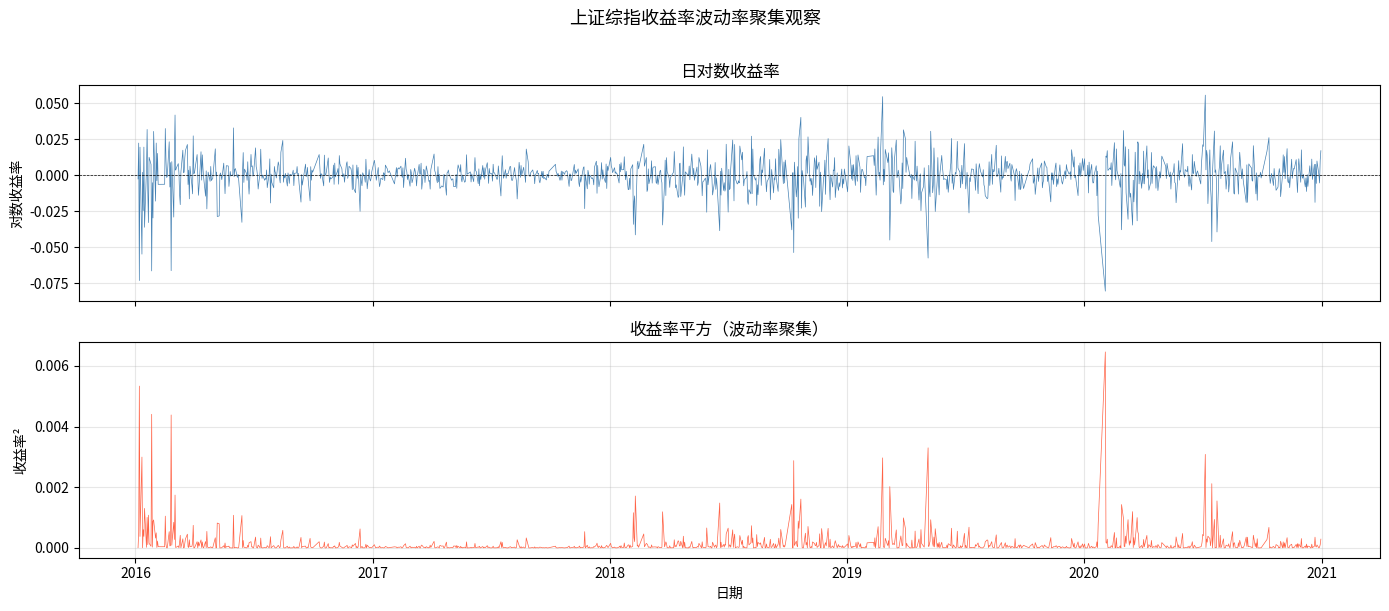

观察：收益率在某些时段（如 2008 年金融危机、2015 年股灾）呈现明显的波动率聚集现象，
这正是 GARCH 模型的适用场景。


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(returns.index, returns.values, linewidth=0.5, color='steelblue')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_title('日对数收益率')
axes[0].set_ylabel('对数收益率')
axes[0].grid(True, alpha=0.3)

axes[1].plot(returns.index, returns.values ** 2, linewidth=0.5, color='tomato')
axes[1].set_title('收益率平方（波动率聚集）')
axes[1].set_ylabel('收益率²')
axes[1].set_xlabel('日期')
axes[1].grid(True, alpha=0.3)

fig.suptitle('上证综指收益率波动率聚集观察', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES / 'garch_volatility_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print('观察：收益率在某些时段（如 2008 年金融危机、2015 年股灾）呈现明显的波动率聚集现象，')
print('这正是 GARCH 模型的适用场景。')

## 3. ARCH 效应检验

对收益率平方进行 Ljung-Box 检验，验证是否存在显著的 ARCH 效应。
p < 0.05 说明存在显著自相关，即 ARCH 效应。

In [5]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_sq = acorr_ljungbox(returns ** 2, lags=10, return_df=True)
display(lb_sq)

if (lb_sq['lb_pvalue'] < 0.05).any():
    print('✓ 检测到显著 ARCH 效应（收益率平方存在自相关），GARCH 建模适用')
else:
    print('✗ 未检测到显著 ARCH 效应，GARCH 建模可能不适用')

,lb_stat,lb_pvalue
1,5.005636,2.526492e-02
2,31.910971,1.176578e-07
3,44.443885,1.214620e-09
4,57.509090,9.674158e-12
5,63.923182,1.874053e-12
6,71.684273,1.844749e-13
7,83.477226,2.685805e-15
8,92.712345,1.307186e-16
9,98.562434,3.072426e-17
10,113.292261,1.154967e-19


✓ 检测到显著 ARCH 效应（收益率平方存在自相关），GARCH 建模适用


In [6]:
# 使用 prepare_returns 进行完整校验
returns_clean = prepare_returns(returns)
print(f'清洗后收益率序列长度: {len(returns_clean)}')

清洗后收益率序列长度: 1217


## 4. 参数搜索

对 GARCH(p, q) 进行网格搜索（p, q ∈ {1, 2}），
以 AIC 为准则选出最优规格。

In [7]:
order_df = search_garch_order(
    returns_clean,
    p_range=(1, 2),
    q_range=(1, 2),
    criterion='aic'
)
print('GARCH 阶次搜索结果（按 AIC 排序）：')
display(order_df)

/data/study/sse_price_volatility/.venv/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001368. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/data/study/sse_price_volatility/.venv/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001368. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/dat

GARCH 阶次搜索结果（按 AIC 排序）：


/data/study/sse_price_volatility/.venv/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001368. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


,p,q,aic,bic,converged
0,1,2,-7697.871117,-7672.350397,True
1,1,1,-7691.613318,-7671.196741,True
2,2,2,-7677.324838,-7646.699973,True
3,2,1,-7676.309922,-7650.789201,True


In [8]:
best_p = int(order_df.iloc[0]['p'])
best_q = int(order_df.iloc[0]['q'])
best_garch_order = (best_p, best_q)
print(f'最优阶次（AIC 最小）: GARCH{best_garch_order}')

最优阶次（AIC 最小）: GARCH(1, 2)


## 5. 模型拟合与样本外预测

调用 `rolling_forecast_garch`，同时完成：
- 在完整训练集上拟合 GARCH 模型（返回 `result`，供后续诊断使用）
- 对测试期逐步滚动预测 1 步条件波动率

滚动窗口 = 训练集长度（固定窗口，不扩张）。
无需单独调用 `fit_garch`。

In [9]:
# 加载测试集
raw_test = load_test()
df_test = preprocess(raw_test)
returns_test = df_test['log_return']
print(f'测试集: {df_test.index.min().date()} ~ {df_test.index.max().date()}, {len(df_test)} 条')

# 用 rolling_forecast_garch 同时完成模型拟合与样本外预测
# 返回 (rolling_df, result): result 为首次在全量训练集上的拟合结果
print(f'使用 GARCH{best_garch_order}，滚动窗口 = {len(returns_clean)}，逐步重新拟合...')
rolling_df, result = rolling_forecast_garch(
    train_data=returns_clean,
    test_data=returns_test,
    order=best_garch_order,
    dist='t',
    vol='Garch',
)
print('滚动预测完成，样本外前 5 行：')
display(rolling_df.head())
print()
print(result.summary())

测试集: 2021-01-05 ~ 2025-12-31, 1211 条
使用 GARCH(1, 2)，滚动窗口 = 1217，逐步重新拟合...
滚动预测完成，样本外前 5 行：


,predicted_variance,predicted_volatility,realized_return
date,,,
2021-01-05,0.000089,0.009445,0.007315
2021-01-06,0.000087,0.009336,0.006272
2021-01-07,0.000085,0.009208,0.007108
2021-01-08,0.000082,0.009080,-0.001706
2021-01-11,0.000079,0.008887,-0.010874



                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1668.90
Distribution:      Standardized Student's t   AIC:                           3349.80
Method:                  Maximum Likelihood   BIC:                           3380.42
                                              No. Observations:                 1217
Date:                      Tue, Apr 07 2026   Df Residuals:                     1216
Time:                              15:36:46   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu 

In [10]:
# 提取关键参数
params = result.params
alpha_sum = sum(v for k, v in params.items() if k.startswith('alpha'))
beta_sum = sum(v for k, v in params.items() if k.startswith('beta'))
persistence = alpha_sum + beta_sum
print(f'\nα 之和: {alpha_sum:.4f}')
print(f'β 之和: {beta_sum:.4f}')
print(f'波动率持久性 (α+β): {persistence:.4f}')
if persistence < 1:
    print('→ 模型协方差平稳（持久性 < 1）')
else:
    print('→ 波动率持久性较高，考虑 IGARCH')


α 之和: 0.0526
β 之和: 0.9372
波动率持久性 (α+β): 0.9898
→ 模型协方差平稳（持久性 < 1）


## 6. 残差诊断

对标准化残差进行诊断，检验 GARCH 模型是否充分捕获了波动率结构：
- 标准化残差 ACF 不应显著
- 标准化残差平方 ACF 不应显著（无剩余 ARCH 效应）

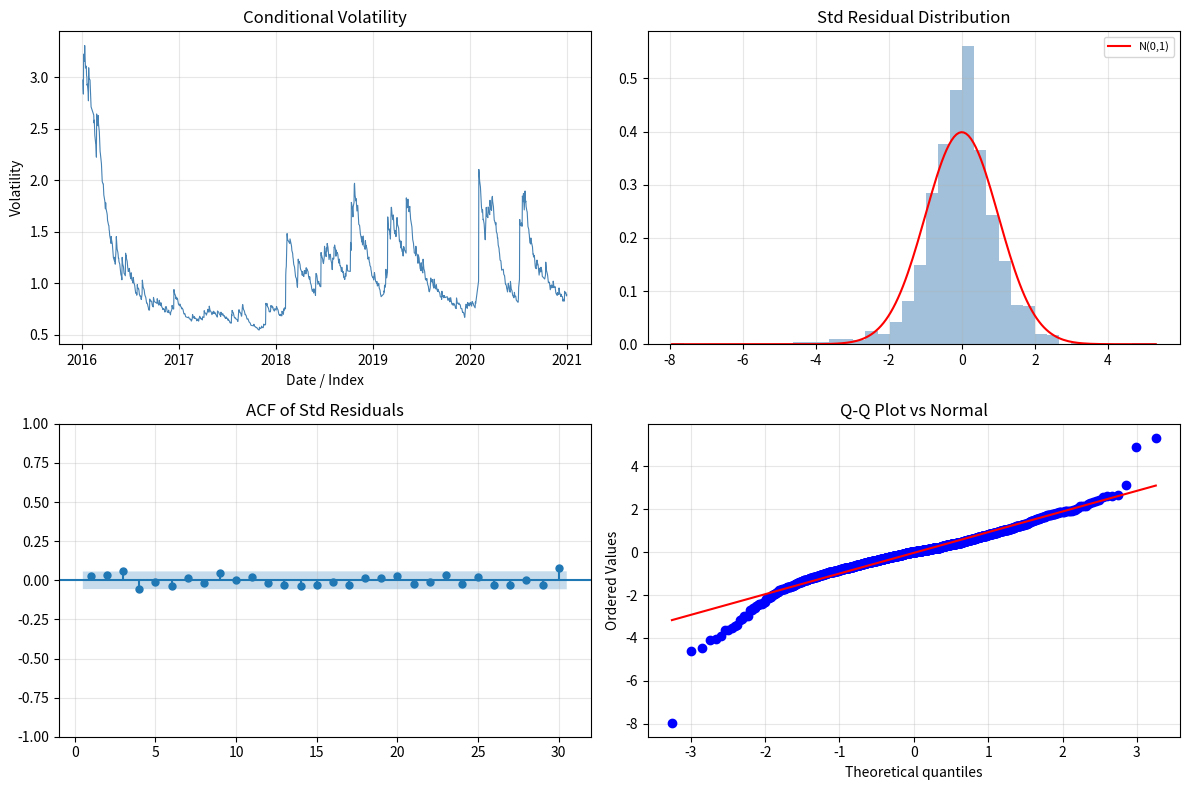

标准化残差统计：


mean       -0.034186
std         0.990934
skew       -0.688241
kurtosis    5.870300
Name: std_residual_stats, dtype: float64

In [11]:
diag = garch_diagnostics(
    result,
    lags=20,
    save_path=FIGURES / 'garch_residual_diagnostics.png'
)
plt.show()

print('标准化残差统计：')
display(diag['summary_stats'])

In [12]:
lb_resid = diag['ljung_box']
lb_resid_sq = diag['ljung_box_sq']

print('标准化残差 Ljung-Box 检验（前 5 滞后）：')
display(lb_resid.head(5))

print('\n标准化残差平方 Ljung-Box 检验（前 5 滞后）：')
display(lb_resid_sq.head(5))

if (lb_resid_sq['lb_pvalue'] > 0.05).all():
    print('\n✓ 标准化残差平方无显著自相关，GARCH 模型已充分捕获波动率聚集')
else:
    print('\n✗ 仍存在剩余 ARCH 效应，考虑提高 GARCH 阶次或换用非对称模型（GJR-GARCH）')

标准化残差 Ljung-Box 检验（前 5 滞后）：


,lb_stat,lb_pvalue
1,0.857284,0.354500
2,2.441433,0.295019
3,6.584481,0.086390
4,10.722104,0.029871
5,10.865198,0.054119



标准化残差平方 Ljung-Box 检验（前 5 滞后）：


,lb_stat,lb_pvalue
1,6.356313,0.011696
2,6.376164,0.041251
3,8.953981,0.029909
4,9.211888,0.056016
5,9.218125,0.100674



✗ 仍存在剩余 ARCH 效应，考虑提高 GARCH 阶次或换用非对称模型（GJR-GARCH）


## 7. 条件波动率

绘制 GARCH 模型估计的训练期条件波动率，
与收益率序列对比，验证模型捕获了波动率聚集现象。

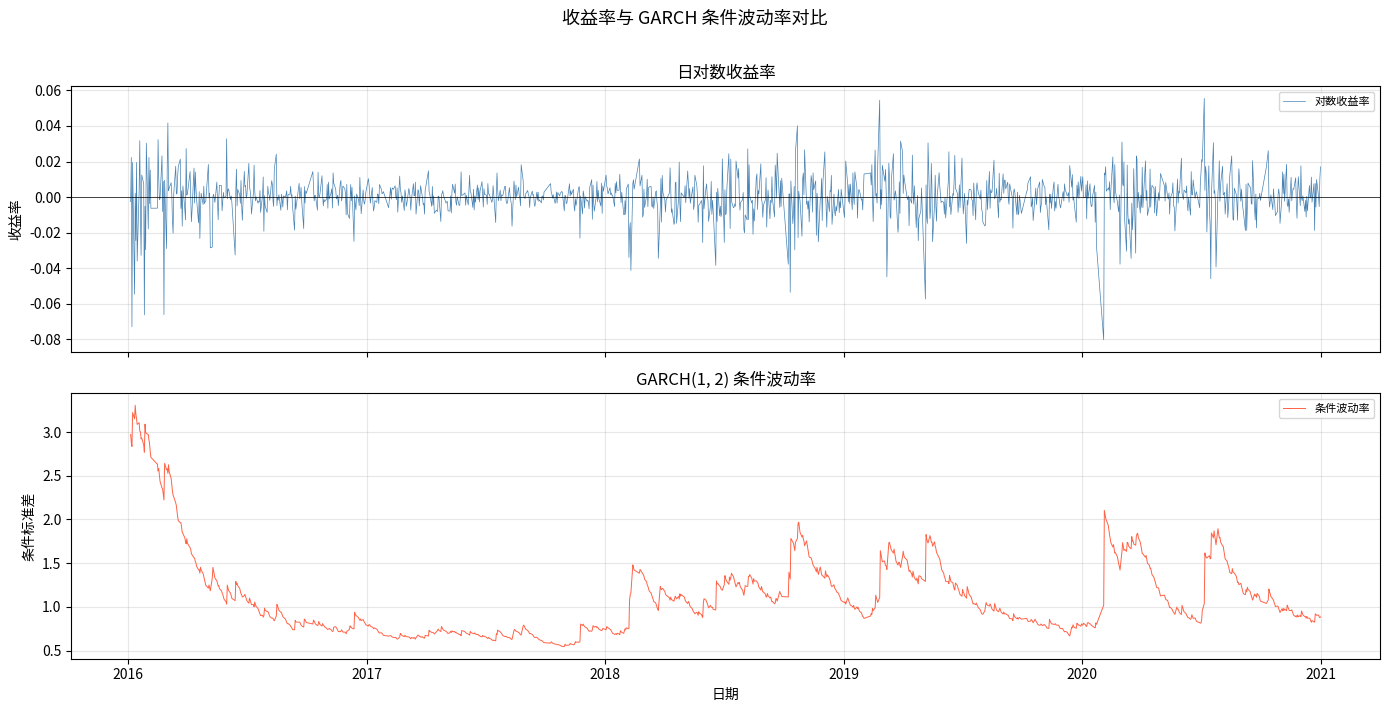

In [13]:
cond_vol = diag['conditional_vol']

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(returns_clean.index, returns_clean.values,
             linewidth=0.5, color='steelblue', label='对数收益率')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('日对数收益率')
axes[0].set_ylabel('收益率')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(cond_vol.index, cond_vol.values,
             linewidth=0.7, color='tomato', label='条件波动率')
axes[1].set_title(f'GARCH{best_garch_order} 条件波动率')
axes[1].set_ylabel('条件标准差')
axes[1].set_xlabel('日期')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.suptitle('收益率与 GARCH 条件波动率对比', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES / 'garch_conditional_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. 滚动样本外预测结果

将第 5 节计算得到的滚动预测波动率与实现波动率代理指标对比：
- `|收益率|` 和 5 日滚动标准差作为实现波动率的代理
- GARCH 预测波动率应与高波动率时段同步上升

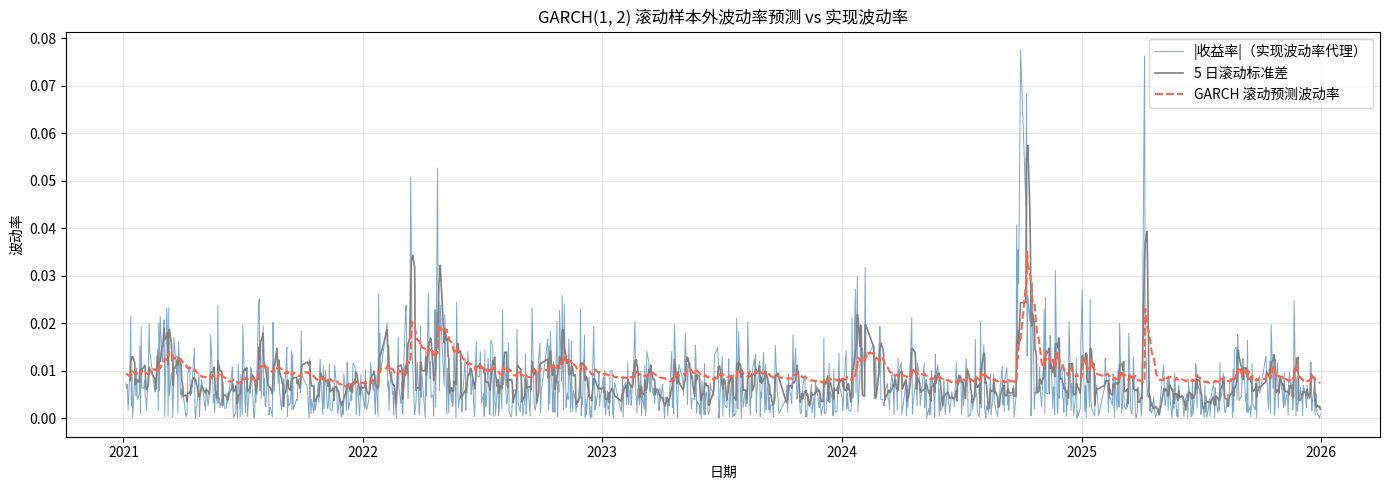

In [14]:
# 实现波动率代理：5 日滚动标准差
realized_vol = returns_test.rolling(5).std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_df.index, np.abs(rolling_df['realized_return'].values),
        linewidth=0.7, color='steelblue', alpha=0.7, label='|收益率|（实现波动率代理）')
ax.plot(realized_vol.index, realized_vol.values,
        linewidth=1.2, color='gray', label='5 日滚动标准差')
ax.plot(rolling_df.index, rolling_df['predicted_volatility'].values,
        linewidth=1.5, color='tomato', linestyle='--', label='GARCH 滚动预测波动率')
ax.set_title(f'GARCH{best_garch_order} 滚动样本外波动率预测 vs 实现波动率')
ax.set_xlabel('日期')
ax.set_ylabel('波动率')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / 'garch_rolling_forecast_vs_realized.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 结论

- **波动率聚集**：上证综指日收益率呈现明显的波动率聚集现象，ARCH 效应检验显著，
  GARCH 模型在理论上是适用的。
- **模型拟合**：GARCH 参数中 α+β 接近 1，说明波动率具有较强的持久性，
  冲击对未来波动率的影响会持续较长时间。
- **残差诊断**：标准化残差平方无显著剩余自相关，模型基本捕获了波动率结构。
- **局限性**：
  - GARCH 对正负冲击的反应是对称的，若存在杠杆效应可考虑 GJR-GARCH 或 EGARCH。
  - 正态分布假设可能低估尾部风险，可尝试 t 分布或偏 t 分布。
  - 本模型仅用于波动率动态刻画，不构成任何投资建议。